In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import pickle
import os

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

class_names = [
    'Not-exposed',
    'At Risk / Concerned',
    'Vulnerable',
    'High Vulnerability'
]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (44806, 23)
X_test:  (11202, 23)


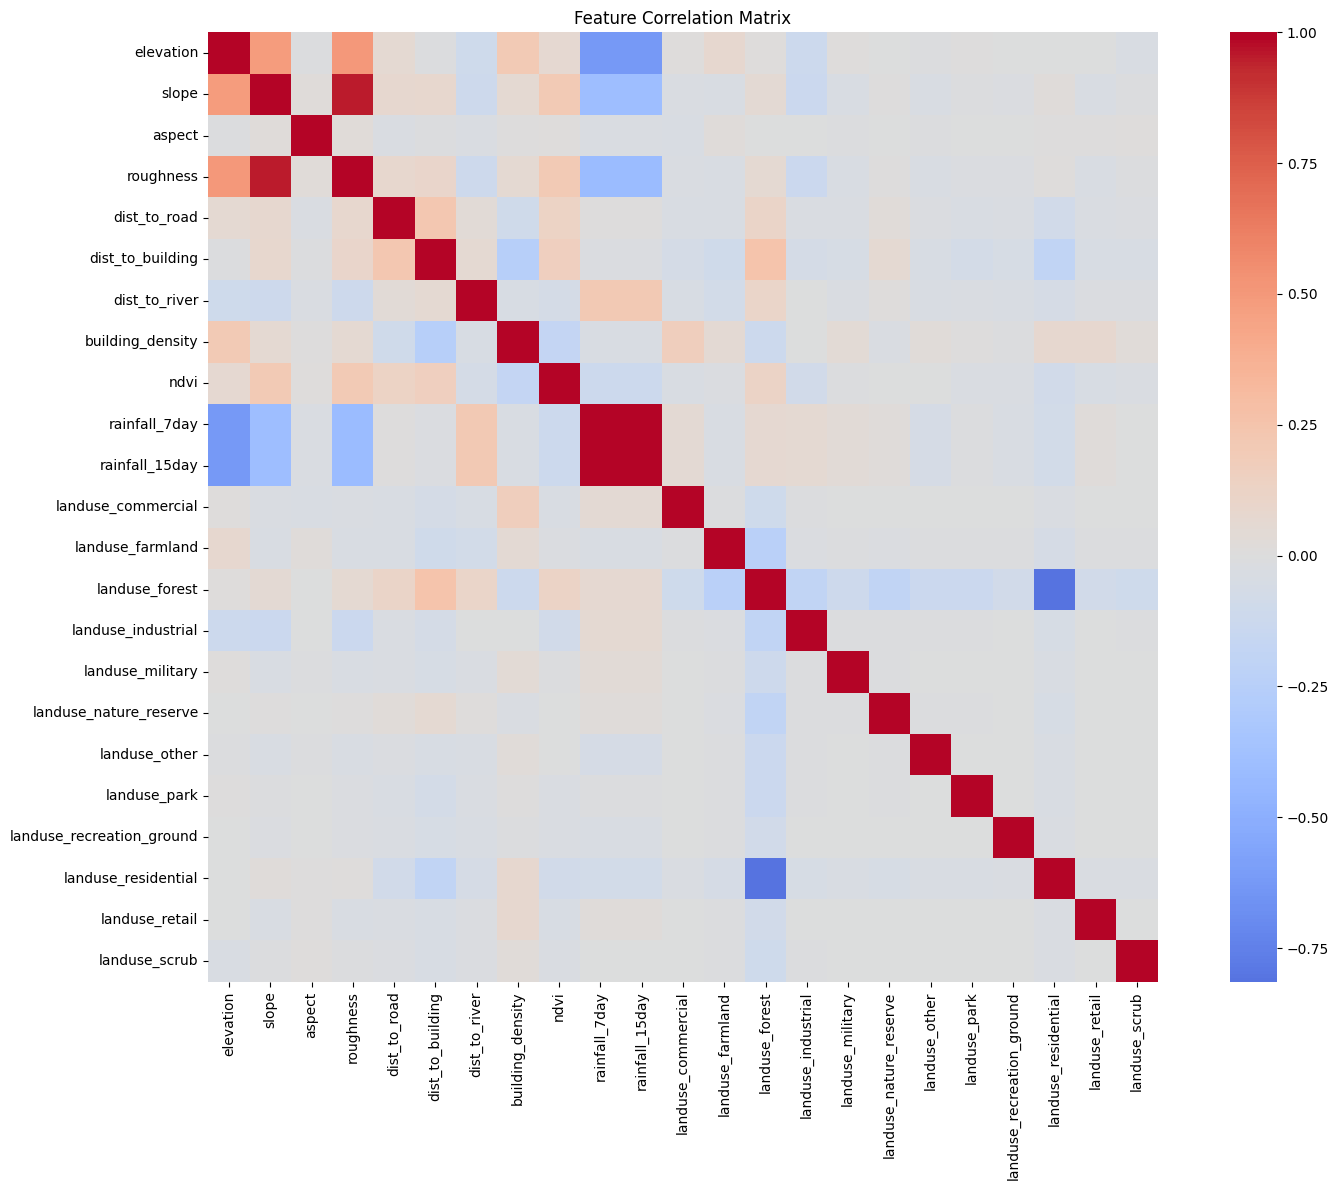

Highly correlated feature pairs (>0.7):
slope ↔ roughness: 0.95
rainfall_7day ↔ rainfall_15day: 1.00
landuse_forest ↔ landuse_residential: -0.81


In [2]:
# Check feature correlations
plt.figure(figsize=(16, 12))
corr = X_train.corr()
sns.heatmap(corr, 
            annot=False, 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_matrix.png")
plt.show()

# Print top correlations with each other
print("Highly correlated feature pairs (>0.7):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.7:
            print(f"{corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i,j]:.2f}")

In [3]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Evaluate
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf_model.predict(X_test))

print(f"Random Forest trained!")
print(f"Training Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy:     {rf_test_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_model.predict(X_test), 
      target_names=class_names))

# Save model
with open("../outputs/models/random_forest.pkl", 'wb') as f:
    pickle.dump(rf_model, f)
print("Model saved!")

Training Random Forest...
Random Forest trained!
Training Accuracy: 0.9862
Test Accuracy:     0.5732

Classification Report:
                     precision    recall  f1-score   support

        Not-exposed       0.75      0.72      0.73      1867
At Risk / Concerned       0.56      0.57      0.57      3710
         Vulnerable       0.41      0.25      0.31      1884
 High Vulnerability       0.55      0.67      0.61      3741

           accuracy                           0.57     11202
          macro avg       0.57      0.55      0.55     11202
       weighted avg       0.56      0.57      0.56     11202

Model saved!


In [4]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_model.predict(X_test))
print(cm)

[[1346  267   79  175]
 [ 205 2106  315 1084]
 [ 109  540  466  769]
 [ 146  821  271 2503]]


In [6]:
print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
xgb_train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
xgb_test_acc  = accuracy_score(y_test,  xgb_model.predict(X_test))

print(f"\nXGBoost trained!")
print(f"Training Accuracy: {xgb_train_acc:.4f}")
print(f"Test Accuracy:     {xgb_test_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_model.predict(X_test),
      target_names=class_names))

# Save model
xgb_model.save_model("../outputs/models/xgboost.json")
print("Model saved!")

Training XGBoost...
[0]	validation_0-mlogloss:1.36906
[100]	validation_0-mlogloss:1.06251
[200]	validation_0-mlogloss:1.04082
[300]	validation_0-mlogloss:1.03085
[400]	validation_0-mlogloss:1.02473
[499]	validation_0-mlogloss:1.02002

XGBoost trained!
Training Accuracy: 0.6829
Test Accuracy:     0.5412

Classification Report:
                     precision    recall  f1-score   support

        Not-exposed       0.79      0.70      0.74      1867
At Risk / Concerned       0.51      0.57      0.54      3710
         Vulnerable       0.38      0.07      0.12      1884
 High Vulnerability       0.50      0.67      0.57      3741

           accuracy                           0.54     11202
          macro avg       0.54      0.50      0.49     11202
       weighted avg       0.53      0.54      0.51     11202

Model saved!


In [8]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# RF metrics
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc  = accuracy_score(y_test, rf_model.predict(X_test))
rf_macro_f1  = f1_score(
    y_test,
    rf_model.predict(X_test),
    average="macro"
)

# XGB metrics
xgb_train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
xgb_test_acc  = accuracy_score(y_test, xgb_model.predict(X_test))
xgb_macro_f1  = f1_score(
    y_test,
    xgb_model.predict(X_test),
    average="macro"
)

# MANUALLY ENTER MLP RESULTS
mlp_train_acc = 0.5421
mlp_test_acc  = 0.5267
mlp_macro_f1  = 0.35  # replace with actual value

results_df = pd.DataFrame({
    "Model": ["MLP", "Random Forest", "XGBoost"],
    "Train Acc": [
        mlp_train_acc,
        rf_train_acc,
        xgb_train_acc
    ],
    "Test Acc": [
        mlp_test_acc,
        rf_test_acc,
        xgb_test_acc
    ],
    "Macro F1": [
        mlp_macro_f1,
        rf_macro_f1,
        xgb_macro_f1
    ]
})

results_df["Gap"] = (
    results_df["Train Acc"]
    - results_df["Test Acc"]
)

print(results_df.round(4))

           Model  Train Acc  Test Acc  Macro F1     Gap
0            MLP     0.5421    0.5267    0.3500  0.0154
1  Random Forest     0.9862    0.5732    0.5533  0.4130
2        XGBoost     0.6829    0.5412    0.4936  0.1416


/var/folders/wr/tfs09wcn2rqdx4n2g4y49jlw0000gn/T/ipykernel_40981/1669022278.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15], palette='viridis')


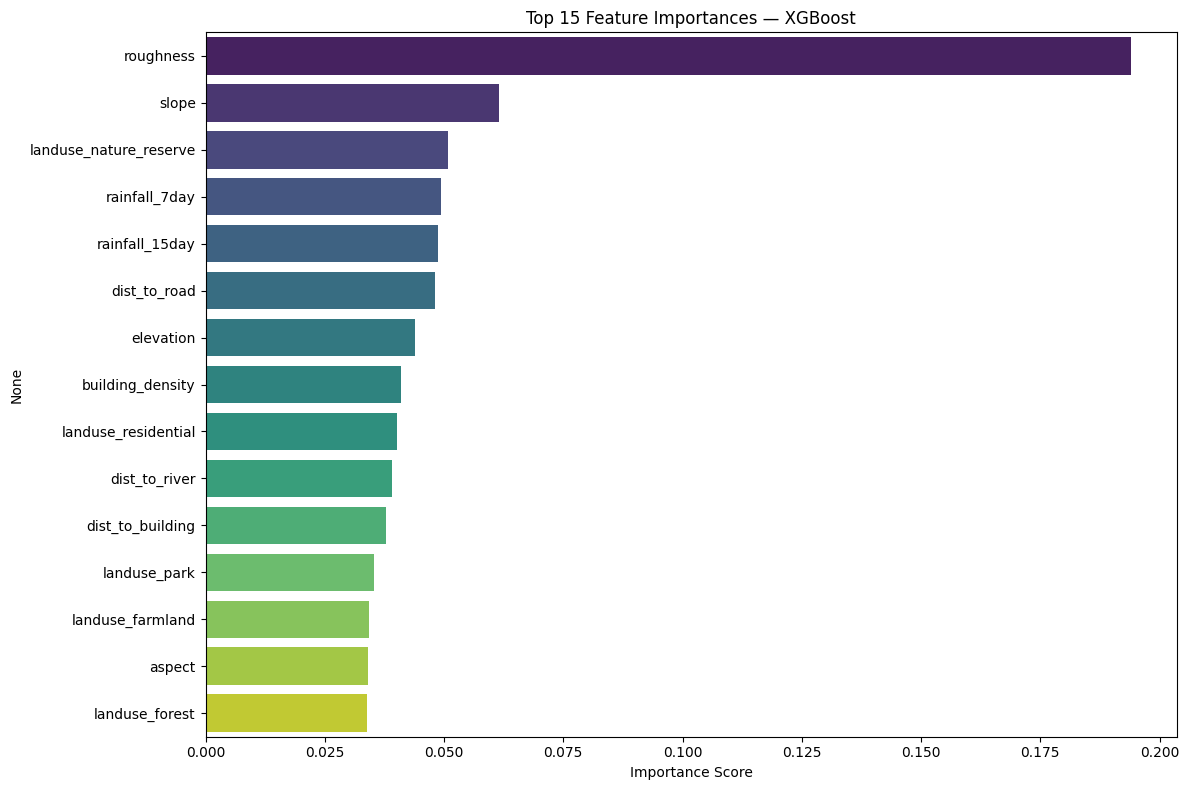

Top 10 most important features:
roughness                 0.193986
slope                     0.061478
landuse_nature_reserve    0.050875
rainfall_7day             0.049331
rainfall_15day            0.048736
dist_to_road              0.048064
elevation                 0.043812
building_density          0.041047
landuse_residential       0.040067
dist_to_river             0.039101
dtype: float32


In [10]:
df = pd.read_csv("../data/processed/final_dataset.csv")

print("Feature means by class:")
print(df.groupby('Exposure')[['elevation', 'slope', 
                               'rainfall_7day', 'ndvi',
                               'dist_to_road']].mean().round(2))

Feature means by class:
                     elevation  slope  rainfall_7day  ndvi  dist_to_road
Exposure                                                                
At Risk                1348.98  20.97          29.56  0.36         55.45
Concerned              1487.34  19.58          29.24  0.44        203.83
Highly Vulnerable      1435.52  21.24          29.23  0.42        156.25
Not-exposed            1070.86   9.26          31.59  0.38        207.01
Severely Vulnerable    1402.31  21.57          29.28  0.41        119.03
Vulnerable             1486.52  21.00          29.09  0.44        183.03


In [12]:
from sklearn.feature_selection import f_classif

X = df.drop(columns=["Exposure"])
y = df["Exposure"]

f_scores, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    "Feature": X.columns,
    "F_score": f_scores,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

print(anova_df.head(15))

ValueError: could not convert string to float: 'KANGRA'